# AutoMorph on FIVES — full pipeline run

The complete 13-stage pipeline over 32 FIVES images, scored against the expert vessel annotations.

Two questions:

1. **How well does M2 reproduce the annotation?** Dice, IoU, sensitivity, specificity.
2. **Do the features AutoMorph reports survive that error?** The same six whole-image features are
   measured from the annotation itself, by the same retipy code, and compared image by image.

The second is the interesting one. A segmentation can lose a quarter of the annotated pixels and
still report an almost-correct fractal dimension, or be pixel-accurate and report a badly wrong
width. Dice alone does not tell you which features to trust.

**The M1 quality gate is enforced in this run**, and it drops 6 of the 32 images before segmentation.
Everything below is therefore conditioned on the survivors. The companion notebook,
`analysis_M2_vessels.ipynb`, bypasses the gate and segments all 32 — read them together.

> `Average_width` is in nominal microns: FIVES publishes no pixel size, so the benchmark writes a
> placeholder 0.008 mm/pixel. Prediction and truth share the same scaling, so every comparison
> statistic here is unaffected; only the absolute micron value is not physical.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

REPO_ROOT = Path.cwd() if (Path.cwd() / "benchmark").is_dir() else Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))

from benchmark.agreement import (
    agreement_table,
    discriminability,
    icc21,
    icc_label,
    informational_strength,
)

FEATURES = [
    "Fractal_dimension",
    "Vessel_density",
    "Average_width",
    "Distance_tortuosity",
    "Squared_curvature_tortuosity",
    "Tortuosity_density",
]

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3, "font.size": 9})
pd.set_option("display.width", 200)
print(f"repository root: {REPO_ROOT}")

repository root: /Users/staskh/Sandbox/AutoMorph


## Load and join

In [2]:
RESULTS = REPO_ROOT / "benchmark" / "results" / "End2End_original"
RUN_RESULTS = REPO_ROOT / ".benchmark_run" / "Results"
RUN_LABEL = "full pipeline, M1 quality gate enforced"
GATE_ENFORCED = True


def strip_suffix(series):
    return series.str.replace(".png", "", regex=False)


scores = pd.read_csv(RESULTS / "vessel_scores.csv")
selection = pd.read_csv(RESULTS / "selection.csv")

predicted = pd.read_csv(RUN_RESULTS / "M3" / "Macular_Features.csv")[["Name"] + FEATURES]
truth = pd.read_csv(RUN_RESULTS / "M3" / "Ground_truth_Macular_Features.csv")[["Name"] + FEATURES]
predicted["key"] = strip_suffix(predicted["Name"])
truth["key"] = strip_suffix(truth["Name"])

# retipy writes -1 for a failed measurement; that is a marker, not a value.
for frame in (predicted, truth):
    frame[FEATURES] = frame[FEATURES].mask(frame[FEATURES] == -1)

paired = (
    predicted.drop(columns="Name")
    .merge(truth.drop(columns="Name"), on="key", suffixes=("_pred", "_gt"))
    .merge(scores[["key", "disease", "status", "dice", "iou", "sensitivity", "specificity"]], on="key")
)
ok = paired[paired["status"] == "ok"]
order = sorted(ok["disease"].unique())

# Ground truth exists for every image, gate or no gate.
truth_all = truth.rename(columns={f: f"{f}_gt" for f in FEATURES})

REJECTED_BY_M1 = set(scores.loc[scores["status"] != "ok", "key"])

print(f"{len(selection)} selected, {(scores['status'] == 'ok').sum()} segmented, {len(ok)} paired")
print()
print(scores["status"].value_counts().to_string())

32 selected, 26 segmented, 26 paired

status
ok                 26
no_segmentation     6


## 1. Where images dropped out

M1 is a gate, not a report: `merge_quality_assessment.py` sorts images into `Good_quality/` or
`Bad_quality/`, and M2 only reads the former. A rejected image yields no segmentation and no
features at all — so the drop-out belongs in the results, not in a footnote.

In [3]:
gate = selection[["key", "disease"]].merge(scores[["key", "status"]], on="key")
gate["reached_segmentation"] = gate["status"] == "ok"

summary = gate.groupby("disease").agg(
    selected=("key", "size"),
    segmented=("reached_segmentation", "sum"),
)
summary["rejected"] = summary["selected"] - summary["segmented"]
summary["rejected_pct"] = (100 * summary["rejected"] / summary["selected"]).round(1)
display(summary)

print("rejected images:", ", ".join(sorted(gate.loc[~gate["reached_segmentation"], "key"])))
print()
print("The vessel-only run segments these anyway and grades the decision.")

,selected,segmented,rejected,rejected_pct
disease,,,,
amd,8,8,0,0.0
dr,8,7,1,12.5
glaucoma,8,8,0,0.0
normal,8,3,5,62.5


rejected images: test_151_N, test_158_N, test_161_N, test_162_N, test_167_N, test_56_D

The vessel-only run segments these anyway and grades the decision.


## 2. Segmentation accuracy

Vessels occupy roughly 2% of the field of view, so **specificity and accuracy sit near 1 for any
prediction** and carry almost no information. Read Dice and IoU; read sensitivity to see which way
the errors fall.

In [4]:
metrics = ["dice", "iou", "sensitivity", "specificity"]

display(ok[metrics].describe().round(4))
display(ok.groupby("disease")[metrics].agg(["mean", "std"]).round(4))

,dice,iou,sensitivity,specificity
count,26.0000,26.0000,26.0000,26.0000
mean,0.8321,0.7155,0.7474,0.9947
std,0.0534,0.0706,0.0792,0.0022
min,0.6196,0.4489,0.4636,0.9909
25%,0.8191,0.6936,0.7174,0.9929
50%,0.8447,0.7314,0.7642,0.9948
75%,0.8632,0.7594,0.7973,0.9965
max,0.8792,0.7845,0.8281,0.9987


dice             iou         sensitivity         specificity        
            mean     std    mean     std        mean     std        mean     std
disease                                                                         
amd       0.8530  0.0255  0.7445  0.0382      0.7761  0.0483      0.9948  0.0016
dr        0.7886  0.0840  0.6573  0.1064      0.6810  0.1155      0.9962  0.0023
glaucoma  0.8420  0.0234  0.7277  0.0350      0.7628  0.0419      0.9941  0.0021
normal    0.8511  0.0307  0.7415  0.0458      0.7844  0.0489      0.9923  0.0006

/var/folders/fr/9n81007x72d8q41sk2r0hsfm0000gn/T/ipykernel_47202/3177343376.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([ok.loc[ok["disease"] == d, "dice"] for d in order], labels=order)


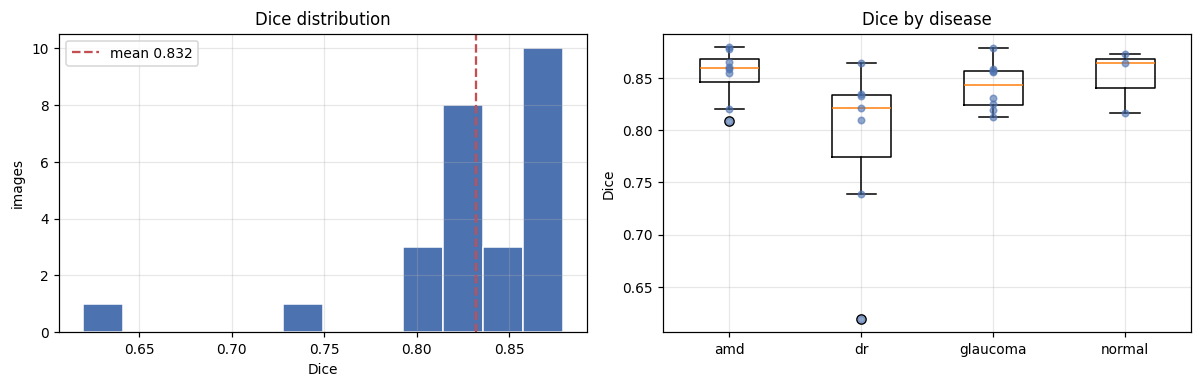

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

axes[0].hist(ok["dice"], bins=12, color="#4C72B0", edgecolor="white")
axes[0].axvline(ok["dice"].mean(), color="#C44E52", ls="--", label=f"mean {ok['dice'].mean():.3f}")
axes[0].set(xlabel="Dice", ylabel="images", title="Dice distribution")
axes[0].legend()

axes[1].boxplot([ok.loc[ok["disease"] == d, "dice"] for d in order], labels=order)
for index, disease in enumerate(order, start=1):
    values = ok.loc[ok["disease"] == disease, "dice"]
    axes[1].scatter(np.full(len(values), index), values, alpha=0.6, s=18, color="#4C72B0", zorder=3)
axes[1].set(ylabel="Dice", title="Dice by disease")

fig.tight_layout()

correlation of Dice with sensitivity: 0.987
correlation of Dice with specificity: -0.589


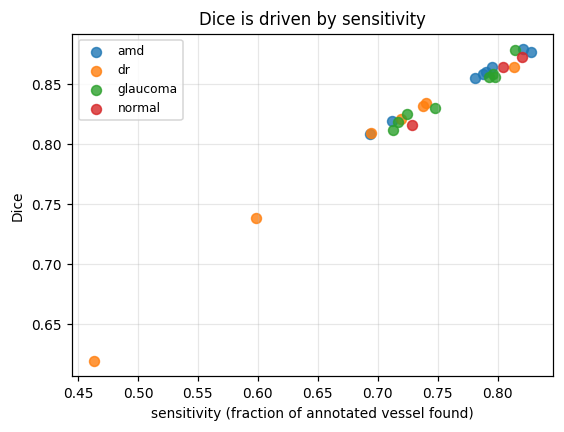

In [6]:
fig, ax = plt.subplots(figsize=(5.2, 4))
for disease in order:
    subset = ok[ok["disease"] == disease]
    ax.scatter(subset["sensitivity"], subset["dice"], label=disease, s=42, alpha=0.8)
ax.set(xlabel="sensitivity (fraction of annotated vessel found)", ylabel="Dice",
       title="Dice is driven by sensitivity")
ax.legend(fontsize=8)
fig.tight_layout()

print("correlation of Dice with sensitivity:", round(ok["dice"].corr(ok["sensitivity"]), 3))
print("correlation of Dice with specificity:", round(ok["dice"].corr(ok["specificity"]), 3))

## 3. Feature agreement

For each feature, predicted against ground truth. Definitions live in `benchmark/agreement.py`,
which is unit-tested — ICC in particular against hand-computed ANOVA values.

- **bias** / **rel_bias_%** — mean signed difference, absolute and as a percentage of the truth's
  mean. A systematic offset, correctable by calibration if it is stable.
- **MAE** / **MAPE_%** — mean absolute error, in the feature's own units and as a percentage.
- **Pearson r** — linear association. Deliberately blind to bias: a constant offset still scores
  1.0. **Spearman** — rank association, which is what matters if the feature orders patients.
- **ICC(2,1)** — intraclass correlation, two-way random effects, absolute agreement, single
  measurement. Unlike Pearson it *charges for systematic bias*, so it is the honest headline
  number. Bands: <0.5 poor, 0.5–0.75 moderate, 0.75–0.9 good, >0.9 excellent. Bootstrap 95%
  intervals are shown because n is small.
- **Bland–Altman limits** — mean difference ± 1.96 SD.

The gap between Pearson and ICC is the interesting column: where Pearson is high and ICC much
lower, the prediction tracks the truth but is offset from it.

In [7]:
agreement = agreement_table(ok, FEATURES, interval=True)

display(
    agreement[
        ["n", "gt_mean", "pred_mean", "bias", "rel_bias_%", "MAE", "MAPE_%",
         "pearson_r", "spearman_r", "ICC21", "ICC_lo", "ICC_hi", "ICC_reading"]
    ].round(3)
)

,n,gt_mean,pred_mean,bias,rel_bias_%,MAE,MAPE_%,pearson_r,spearman_r,ICC21,ICC_lo,ICC_hi,ICC_reading
feature,,,,,,,,,,,,,
Fractal_dimension,26,1.473,1.445,-0.028,-1.918,0.028,1.938,0.938,0.914,0.747,0.564,0.843,moderate
Vessel_density,26,0.083,0.067,-0.017,-20.008,0.017,20.846,0.939,0.908,0.504,0.255,0.652,moderate
Average_width,26,114.106,100.069,-14.037,-12.302,14.037,12.313,0.789,0.838,0.353,0.221,0.460,poor
Distance_tortuosity,26,3.467,3.833,0.366,10.561,0.858,25.764,0.465,0.642,0.443,0.187,0.747,poor
Squared_curvature_tortuosity,26,22.922,29.509,6.587,28.737,16.044,89.325,0.097,0.173,0.088,-0.155,0.498,poor
Tortuosity_density,26,0.691,0.687,-0.003,-0.498,0.022,3.246,0.802,0.791,0.805,0.612,0.898,good


In [8]:
# Where does ICC disagree with Pearson? That gap is exactly the systematic bias.
gap = pd.DataFrame(
    {
        "pearson_r": agreement["pearson_r"],
        "ICC21": agreement["ICC21"],
        "pearson_minus_ICC": agreement["pearson_r"] - agreement["ICC21"],
        "rel_bias_%": agreement["rel_bias_%"],
    }
).sort_values("pearson_minus_ICC", ascending=False)

display(gap.round(3))
print("A large gap means the prediction tracks the truth but sits offset from it.")

,pearson_r,ICC21,pearson_minus_ICC,rel_bias_%
feature,,,,
Average_width,0.789,0.353,0.435,-12.302
Vessel_density,0.939,0.504,0.435,-20.008
Fractal_dimension,0.938,0.747,0.191,-1.918
Distance_tortuosity,0.465,0.443,0.022,10.561
Squared_curvature_tortuosity,0.097,0.088,0.009,28.737
Tortuosity_density,0.802,0.805,-0.003,-0.498


A large gap means the prediction tracks the truth but sits offset from it.


In [9]:
# Is the linear agreement statistically distinguishable from zero at this sample size?
for feature in FEATURES:
    pair = ok[[f"{feature}_pred", f"{feature}_gt"]].dropna()
    r, p = stats.pearsonr(pair[f"{feature}_pred"], pair[f"{feature}_gt"])
    rho, p_rho = stats.spearmanr(pair[f"{feature}_pred"], pair[f"{feature}_gt"])
    verdict = "" if p < 0.05 else "   <-- not significant"
    print(f"{feature:32s} n={len(pair):3d}  r={r:6.3f} (p={p:.2g})   rho={rho:6.3f} (p={p_rho:.2g}){verdict}")

Fractal_dimension                n= 26  r= 0.938 (p=1.5e-12)   rho= 0.914 (p=7.1e-11)
Vessel_density                   n= 26  r= 0.939 (p=1.2e-12)   rho= 0.908 (p=1.4e-10)
Average_width                    n= 26  r= 0.789 (p=1.7e-06)   rho= 0.838 (p=9.2e-08)
Distance_tortuosity              n= 26  r= 0.465 (p=0.017)   rho= 0.642 (p=0.0004)
Squared_curvature_tortuosity     n= 26  r= 0.097 (p=0.64)   rho= 0.173 (p=0.4)   <-- not significant
Tortuosity_density               n= 26  r= 0.802 (p=8.6e-07)   rho= 0.791 (p=1.5e-06)


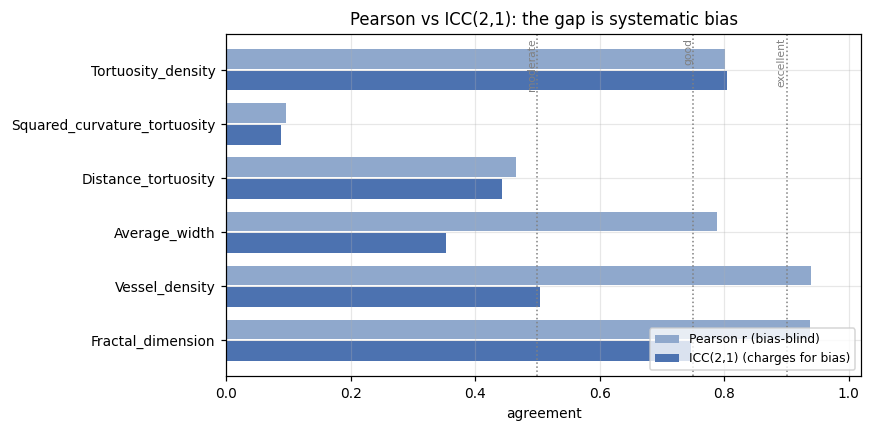

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
position = np.arange(len(FEATURES))

ax.barh(position + 0.2, agreement.loc[FEATURES, "pearson_r"], height=0.36,
        label="Pearson r (bias-blind)", color="#8FA8CC")
ax.barh(position - 0.2, agreement.loc[FEATURES, "ICC21"], height=0.36,
        label="ICC(2,1) (charges for bias)", color="#4C72B0")

for threshold, name in ((0.9, "excellent"), (0.75, "good"), (0.5, "moderate")):
    ax.axvline(threshold, color="grey", ls=":", lw=1)
    ax.text(threshold, len(FEATURES) - 0.4, name, fontsize=7, rotation=90,
            va="top", ha="right", color="grey")

ax.set(yticks=position, yticklabels=FEATURES, xlabel="agreement", xlim=(0, 1.02),
       title="Pearson vs ICC(2,1): the gap is systematic bias")
ax.legend(fontsize=8, loc="lower right")
fig.tight_layout()

### Does any single image carry the result?

At this sample size one extreme value can manufacture a correlation. Leave-one-out on the ICC finds
it: if dropping a single image moves ICC by more than about 0.15, the agreement is that image's
doing, not the model's.

This is not hypothetical — in the vessel-only run `Squared_curvature_tortuosity` scores ICC 0.544
until one 13x outlier is removed, whereupon it collapses to 0.144. Spearman, being rank-based, is
immune to leverage and stays low throughout, which is why both are reported.

In [11]:
rows = []
for feature in FEATURES:
    pair = ok[["key", f"{feature}_pred", f"{feature}_gt"]].dropna()
    predicted = pair[f"{feature}_pred"].to_numpy()
    reference = pair[f"{feature}_gt"].to_numpy()
    full = icc21(predicted, reference)

    worst_key, worst_icc = None, full
    for position in range(len(pair)):
        keep = np.arange(len(pair)) != position
        without = icc21(predicted[keep], reference[keep])
        if abs(without - full) > abs(worst_icc - full):
            worst_key, worst_icc = pair["key"].iloc[position], without

    rows.append(
        {
            "feature": feature,
            "ICC_all": full,
            "most_influential_image": worst_key,
            "ICC_without_it": worst_icc,
            "swing": worst_icc - full,
            "fragile": abs(worst_icc - full) > 0.15,
        }
    )

leverage = pd.DataFrame(rows).set_index("feature")
display(leverage.round(3))

fragile = leverage[leverage["fragile"]]
if len(fragile):
    print("Leverage-dependent — do not read the ICC point estimate alone:")
    for feature, row in fragile.iterrows():
        print(f"  {feature}: {row['ICC_all']:.3f} -> {row['ICC_without_it']:.3f} "
              f"without {row['most_influential_image']}")
else:
    print("No single image moves any ICC by more than 0.15.")

,ICC_all,most_influential_image,ICC_without_it,swing,fragile
feature,,,,,
Fractal_dimension,0.747,test_52_D,0.665,-0.082,False
Vessel_density,0.504,test_52_D,0.388,-0.116,False
Average_width,0.353,test_16_A,0.319,-0.035,False
Distance_tortuosity,0.443,test_105_G,0.623,0.180,True
Squared_curvature_tortuosity,0.088,test_117_G,0.257,0.169,True
Tortuosity_density,0.805,test_58_D,0.852,0.047,False


Leverage-dependent — do not read the ICC point estimate alone:
  Distance_tortuosity: 0.443 -> 0.623 without test_105_G
  Squared_curvature_tortuosity: 0.088 -> 0.257 without test_117_G


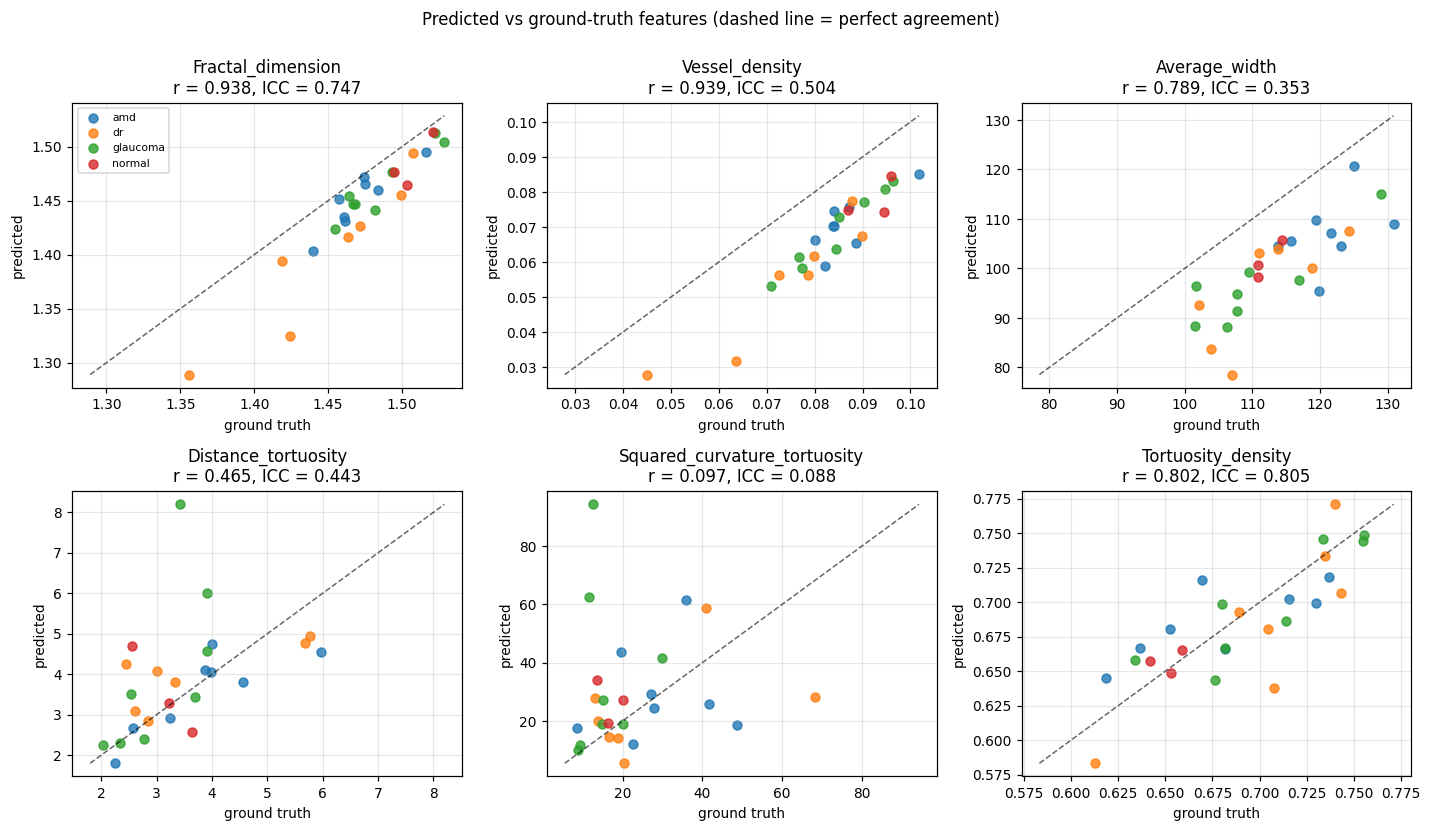

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7.5))

for ax, feature in zip(axes.ravel(), FEATURES):
    pair = ok[[f"{feature}_pred", f"{feature}_gt", "disease"]].dropna()
    for disease in order:
        subset = pair[pair["disease"] == disease]
        ax.scatter(subset[f"{feature}_gt"], subset[f"{feature}_pred"], label=disease, s=34, alpha=0.8)

    combined_values = pd.concat([pair[f"{feature}_gt"], pair[f"{feature}_pred"]])
    limits = [combined_values.min(), combined_values.max()]
    ax.plot(limits, limits, "k--", lw=1, alpha=0.6)
    r = pair[f"{feature}_pred"].corr(pair[f"{feature}_gt"])
    ax.set(xlabel="ground truth", ylabel="predicted",
           title=f"{feature}\nr = {r:.3f}, ICC = {agreement.loc[feature, 'ICC21']:.3f}")

axes[0, 0].legend(fontsize=7)
fig.suptitle("Predicted vs ground-truth features (dashed line = perfect agreement)", y=1.0)
fig.tight_layout()

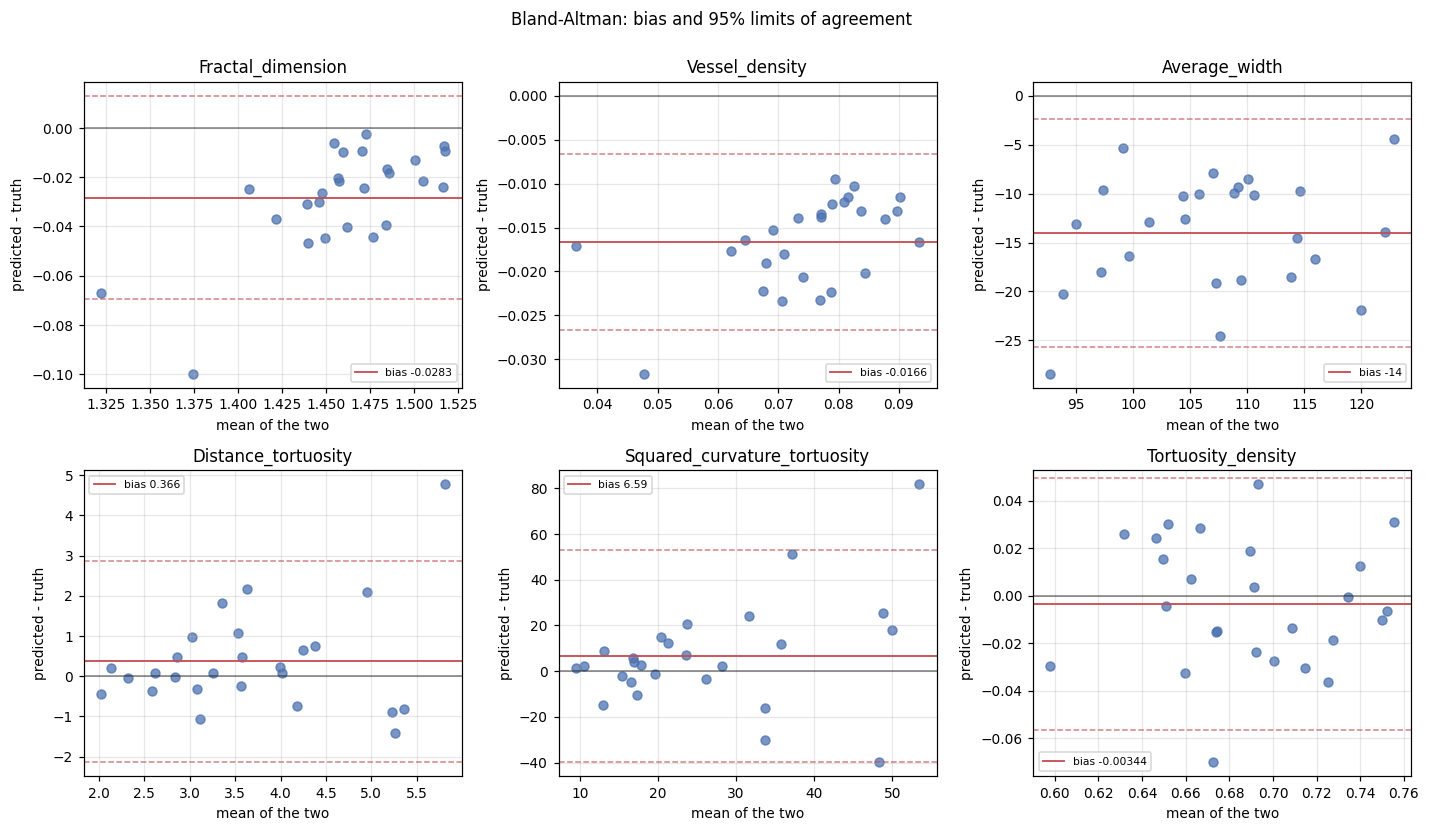

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7.5))

for ax, feature in zip(axes.ravel(), FEATURES):
    pair = ok[[f"{feature}_pred", f"{feature}_gt"]].dropna()
    mean = (pair[f"{feature}_pred"] + pair[f"{feature}_gt"]) / 2
    difference = pair[f"{feature}_pred"] - pair[f"{feature}_gt"]

    ax.scatter(mean, difference, s=34, alpha=0.75, color="#4C72B0")
    ax.axhline(0, color="k", lw=1, alpha=0.5)
    ax.axhline(difference.mean(), color="#C44E52", lw=1.2, label=f"bias {difference.mean():.3g}")
    for limit in (difference.mean() - 1.96 * difference.std(), difference.mean() + 1.96 * difference.std()):
        ax.axhline(limit, color="#C44E52", ls="--", lw=1, alpha=0.7)
    ax.set(xlabel="mean of the two", ylabel="predicted - truth", title=feature)
    ax.legend(fontsize=7)

fig.suptitle("Bland-Altman: bias and 95% limits of agreement", y=1.0)
fig.tight_layout()

## 4. Does Dice predict feature error?

If it does, Dice is a usable proxy for feature trustworthiness on unlabelled data — the only
situation that matters in practice, since you will not have annotations. If it does not, a good Dice
is no guarantee that the reported morphometry is right.

In [14]:
rows = []
for feature in FEATURES:
    pair = ok[[f"{feature}_pred", f"{feature}_gt", "dice", "sensitivity"]].dropna()
    relative_error = (pair[f"{feature}_pred"] - pair[f"{feature}_gt"]).abs() / pair[f"{feature}_gt"].abs()
    rows.append(
        {
            "feature": feature,
            "corr(dice, |rel err|)": pair["dice"].corr(relative_error),
            "corr(sens, |rel err|)": pair["sensitivity"].corr(relative_error),
            "median_|rel err|_%": 100 * relative_error.median(),
        }
    )

proxy_table = pd.DataFrame(rows).set_index("feature")
display(proxy_table.round(3))

,"corr(dice, |rel err|)","corr(sens, |rel err|)",median_|rel err|_%
feature,,,
Fractal_dimension,-0.939,-0.945,1.601
Vessel_density,-0.960,-0.992,18.646
Average_width,-0.731,-0.752,11.631
Distance_tortuosity,-0.062,-0.089,16.027
Squared_curvature_tortuosity,-0.050,-0.098,43.318
Tortuosity_density,-0.188,-0.199,3.056


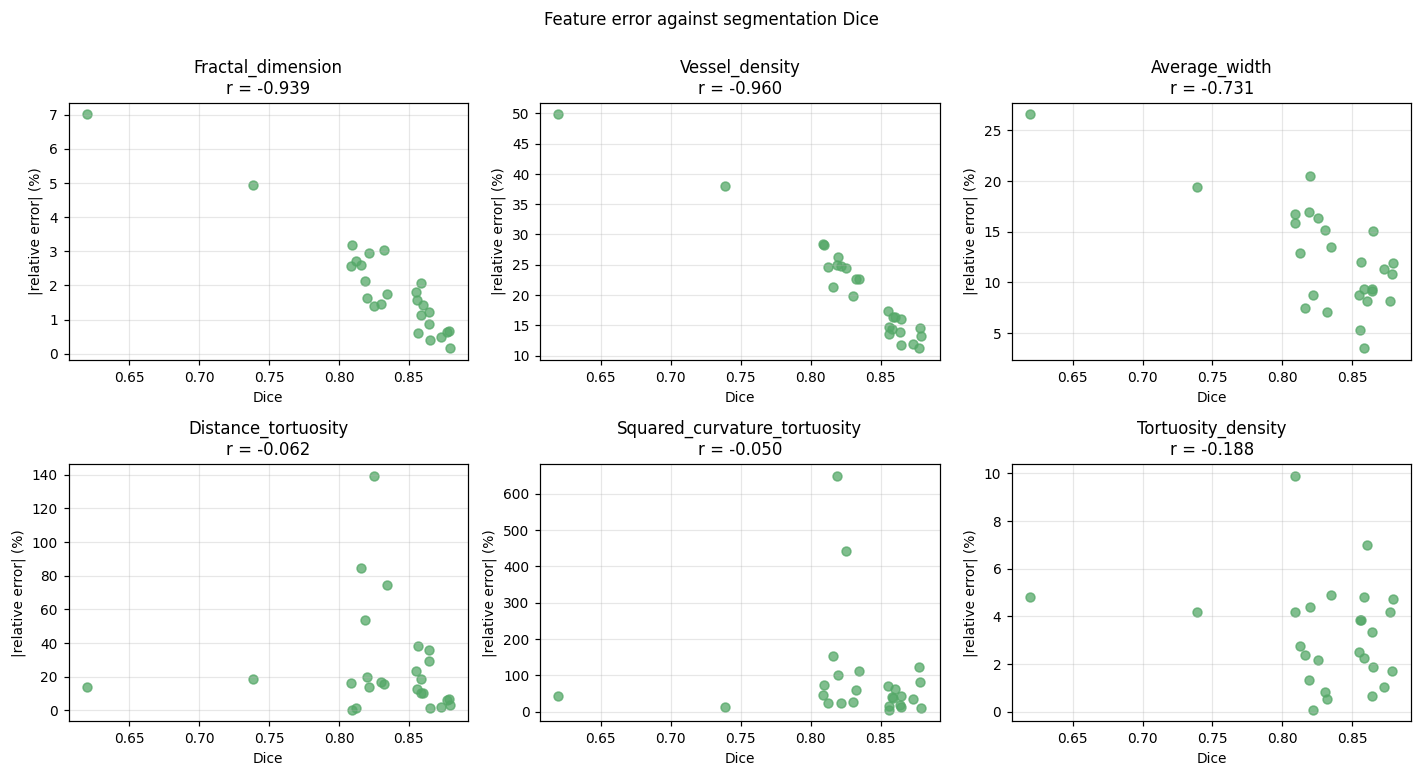

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))

for ax, feature in zip(axes.ravel(), FEATURES):
    pair = ok[[f"{feature}_pred", f"{feature}_gt", "dice"]].dropna()
    relative_error = 100 * (pair[f"{feature}_pred"] - pair[f"{feature}_gt"]).abs() / pair[f"{feature}_gt"].abs()
    ax.scatter(pair["dice"], relative_error, s=34, alpha=0.75, color="#55A868")
    ax.set(xlabel="Dice", ylabel="|relative error| (%)",
           title=f"{feature}\nr = {pair['dice'].corr(relative_error):.3f}")

fig.suptitle("Feature error against segmentation Dice", y=1.0)
fig.tight_layout()

## 5. Per-disease agreement

Small groups — read as indicative, not conclusive.

In [16]:
for disease in order:
    subset = ok[ok["disease"] == disease]
    print(f"\n=== {disease}  (n={len(subset)}, mean Dice {subset['dice'].mean():.3f}) ===")
    display(
        agreement_table(subset, FEATURES)[
            ["rel_bias_%", "MAE", "MAPE_%", "pearson_r", "spearman_r", "ICC21"]
        ].round(3)
    )


=== amd  (n=8, mean Dice 0.853) ===


,rel_bias_%,MAE,MAPE_%,pearson_r,spearman_r,ICC21
feature,,,,,,
Fractal_dimension,-1.332,0.020,1.335,0.905,0.810,0.690
Vessel_density,-18.145,0.016,18.182,0.763,0.571,0.231
Average_width,-11.660,14.130,11.599,0.395,0.357,0.110
Distance_tortuosity,-5.936,0.508,12.466,0.826,0.786,0.820
Squared_curvature_tortuosity,0.263,15.114,57.959,0.133,0.190,0.146
Tortuosity_density,0.987,0.026,3.897,0.765,0.714,0.692



=== dr  (n=7, mean Dice 0.789) ===


,rel_bias_%,MAE,MAPE_%,pearson_r,spearman_r,ICC21
feature,,,,,,
Fractal_dimension,-3.357,0.049,3.393,0.941,0.964,0.701
Vessel_density,-26.710,0.020,28.285,0.934,0.964,0.552
Average_width,-14.286,15.939,14.360,0.747,0.750,0.307
Distance_tortuosity,8.215,0.797,24.783,0.756,0.571,0.653
Squared_curvature_tortuosity,-12.003,14.305,52.743,0.461,0.250,0.485
Tortuosity_density,-2.548,0.028,3.968,0.859,0.750,0.796



=== glaucoma  (n=8, mean Dice 0.842) ===


,rel_bias_%,MAE,MAPE_%,pearson_r,spearman_r,ICC21
feature,,,,,,
Fractal_dimension,-1.452,0.022,1.455,0.948,0.762,0.747
Vessel_density,-18.518,0.016,18.907,0.974,0.976,0.437
Average_width,-12.397,13.644,12.363,0.875,0.786,0.401
Distance_tortuosity,32.745,1.171,35.040,0.645,0.738,0.360
Squared_curvature_tortuosity,133.653,20.722,160.579,0.045,0.405,0.015
Tortuosity_density,-0.633,0.018,2.669,0.878,0.881,0.887



=== normal  (n=3, mean Dice 0.851) ===


,rel_bias_%,MAE,MAPE_%,pearson_r,spearman_r,ICC21
feature,,,,,,
Fractal_dimension,-1.435,0.022,1.438,0.835,0.5,0.468
Vessel_density,-15.789,0.015,15.760,0.595,0.5,0.127
Average_width,-9.289,10.401,9.309,0.948,1.0,0.121
Distance_tortuosity,12.349,1.100,38.776,-0.998,-1.0,-1.616
Squared_curvature_tortuosity,60.759,10.103,68.316,-0.411,-0.5,-0.146
Tortuosity_density,0.924,0.009,1.363,0.342,0.5,0.334


## 6. Informational strength of each feature

Agreement is only half the question. A feature also has to **vary between eyes**, or it cannot
separate them however precisely it is measured.

Informational strength is `IQR / median` over the **ground truth** — a robust, unit-free measure of
how much spread the feature has in the population. It says nothing about AutoMorph; it is a property
of the feature and this cohort, so it is computed over every annotated image, not only the ones that
produced a prediction.

In [17]:
strength = informational_strength(truth_all, FEATURES).sort_values(
    "gt_IQR_over_median", ascending=False
)
display(strength.round(4))

,n,gt_median,gt_IQR,gt_IQR_over_median
feature,,,,
Squared_curvature_tortuosity,32,19.8782,14.6686,0.7379
Distance_tortuosity,32,3.3799,1.2621,0.3734
Average_width,32,114.1119,11.9892,0.1051
Vessel_density,32,0.0845,0.0088,0.1041
Tortuosity_density,32,0.6891,0.0699,0.1014
Fractal_dimension,32,1.4728,0.0336,0.0228


### Spread against noise

`spread_to_noise` is the ground-truth IQR divided by the standard deviation of the prediction error,
with systematic bias excluded — a constant offset does not stop a feature separating one eye from
another, but random scatter does.

Below about 1 the measurement noise covers the feature's whole interquartile range: even a
"low-error" feature cannot rank eyes if its spread is narrower than its error.

In [18]:
combined = discriminability(agreement, informational_strength(ok, FEATURES))
combined["MAPE_%"] = agreement["MAPE_%"]
combined["ICC21"] = agreement["ICC21"]
display(combined.sort_values("spread_to_noise", ascending=False).round(3))

,gt_IQR_over_median,error_sd,spread_to_noise,MAPE_%,ICC21
feature,,,,,
Tortuosity_density,0.114,0.027,2.899,3.246,0.805
Vessel_density,0.126,0.005,2.067,20.846,0.504
Average_width,0.105,5.918,2.027,12.313,0.353
Fractal_dimension,0.025,0.021,1.751,1.938,0.747
Distance_tortuosity,0.404,1.280,1.037,25.764,0.443
Squared_curvature_tortuosity,0.737,23.645,0.599,89.325,0.088


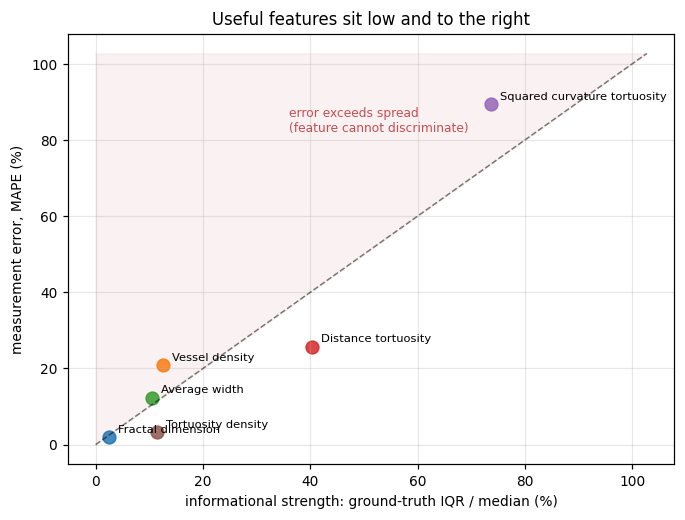

In [19]:
fig, ax = plt.subplots(figsize=(6.4, 4.8))

for feature in FEATURES:
    ax.scatter(combined.loc[feature, "gt_IQR_over_median"] * 100,
               agreement.loc[feature, "MAPE_%"], s=70, alpha=0.85)
    ax.annotate(feature.replace("_", " "),
                (combined.loc[feature, "gt_IQR_over_median"] * 100, agreement.loc[feature, "MAPE_%"]),
                fontsize=7.5, xytext=(6, 3), textcoords="offset points")

ceiling = max(combined["gt_IQR_over_median"].max() * 100, agreement["MAPE_%"].max()) * 1.15
ax.plot([0, ceiling], [0, ceiling], "k--", lw=1, alpha=0.5)
ax.fill_between([0, ceiling], [0, ceiling], ceiling, color="#C44E52", alpha=0.07)
ax.text(ceiling * 0.35, ceiling * 0.8, "error exceeds spread\n(feature cannot discriminate)",
        fontsize=8, color="#C44E52")

ax.set(xlabel="informational strength: ground-truth IQR / median (%)",
       ylabel="measurement error, MAPE (%)",
       title="Useful features sit low and to the right")
fig.tight_layout()

## 7. Verdict per feature

Generated from the numbers above rather than hand-written, so it cannot drift out of sync with the
data. The thresholds are judgement calls, stated explicitly in the code so they can be argued with.
A feature whose ICC depends on one image is judged on the leave-one-out value, not the headline.

In [20]:
def verdict(feature):
    icc = agreement.loc[feature, "ICC21"]
    if leverage.loc[feature, "fragile"]:
        icc = leverage.loc[feature, "ICC_without_it"]        # judge on the robust value
    if not np.isfinite(icc):
        # icc21 returns NaN for a feature that is constant across subjects: there is no
        # between-subject variance for an agreement coefficient to be a ratio of.
        return "unusable - constant across eyes, no agreement is definable"
    spearman = agreement.loc[feature, "spearman_r"]
    mape = agreement.loc[feature, "MAPE_%"]
    bias = abs(agreement.loc[feature, "rel_bias_%"])
    ratio = combined.loc[feature, "spread_to_noise"]

    if icc < 0.5 and spearman < 0.5:
        return "unusable - no agreement with truth"
    if ratio < 1.0:
        return "error covers the population spread - cannot rank eyes"
    if bias > 10:
        return "rank-usable, biased - calibrate before quoting absolutes"
    if mape < 5 and icc >= 0.75:
        return "reliable"
    return "usable with care"


verdicts = pd.DataFrame(
    {
        "rel_bias_%": agreement["rel_bias_%"],
        "MAE": agreement["MAE"],
        "MAPE_%": agreement["MAPE_%"],
        "pearson_r": agreement["pearson_r"],
        "spearman_r": agreement["spearman_r"],
        "ICC21": agreement["ICC21"],
        "ICC_robust": leverage["ICC_without_it"].where(leverage["fragile"], agreement["ICC21"]),
        "gt_IQR_over_median": combined["gt_IQR_over_median"],
        "spread_to_noise": combined["spread_to_noise"],
    }
)
verdicts["verdict"] = [verdict(feature) for feature in verdicts.index]
display(verdicts.round(3).sort_values("ICC_robust", ascending=False))

,rel_bias_%,MAE,MAPE_%,pearson_r,spearman_r,ICC21,ICC_robust,gt_IQR_over_median,spread_to_noise,verdict
feature,,,,,,,,,,
Tortuosity_density,-0.498,0.022,3.246,0.802,0.791,0.805,0.805,0.114,2.899,reliable
Fractal_dimension,-1.918,0.028,1.938,0.938,0.914,0.747,0.747,0.025,1.751,usable with care
Distance_tortuosity,10.561,0.858,25.764,0.465,0.642,0.443,0.623,0.404,1.037,"rank-usable, biased - calibrate before quoting..."
Vessel_density,-20.008,0.017,20.846,0.939,0.908,0.504,0.504,0.126,2.067,"rank-usable, biased - calibrate before quoting..."
Average_width,-12.302,14.037,12.313,0.789,0.838,0.353,0.353,0.105,2.027,"rank-usable, biased - calibrate before quoting..."
Squared_curvature_tortuosity,28.737,16.044,89.325,0.097,0.173,0.088,0.257,0.737,0.599,unusable - no agreement with truth


## 8. Conclusions

Generated from the run below, so the prose cannot drift from the numbers.

In [21]:
lines = [f"RUN: {RUN_LABEL}", ""]

lines += [
    "SEGMENTATION",
    f"  Dice {ok['dice'].mean():.3f}, sensitivity {ok['sensitivity'].mean():.3f}, "
    f"specificity {ok['specificity'].mean():.3f} over n={len(ok)}.",
    f"  The model under-segments: it misses ~{100 * (1 - ok['sensitivity'].mean()):.0f}% of annotated"
    " vessel and invents almost none.",
    f"  Dice correlates with sensitivity at r={ok['dice'].corr(ok['sensitivity']):.3f}, so here Dice"
    " is largely a restatement of sensitivity.",
    "",
    "QUALITY GATE",
]

if GATE_ENFORCED:
    dropped = int((scores["status"] != "ok").sum())
    lines += [
        f"  Enforced. It rejected {dropped} of {len(scores)} FIVES quality-3 images; rejection is"
        " silent and total.",
        "  Feature results below are conditioned on the survivors, so they are optimistic.",
    ]
elif REJECTED_BY_M1:
    inside = ok[ok["key"].isin(REJECTED_BY_M1)]["dice"]
    outside = ok[~ok["key"].isin(REJECTED_BY_M1)]["dice"]
    _, p_gate = stats.mannwhitneyu(inside, outside)
    lines += [
        f"  Bypassed; all {len(ok)} images segmented.",
        f"  The {len(inside)} images M1 would have rejected score Dice {inside.mean():.3f} against"
        f" {outside.mean():.3f} for the rest (Mann-Whitney p={p_gate:.3f}).",
        f"  Discarding them would raise mean Dice by {outside.mean() - ok['dice'].mean():+.4f} while"
        f" losing {100 * len(inside) / len(ok):.0f}% of the cohort.",
    ]
else:
    lines += [f"  Bypassed; all {len(ok)} images segmented."]

lines += ["", "FEATURE AGREEMENT"]
for feature in verdicts.sort_values("ICC_robust", ascending=False).index:
    row = verdicts.loc[feature]
    note = "  (leverage-adjusted)" if leverage.loc[feature, "fragile"] else ""
    lines.append(
        f"  {feature:30s} ICC={row['ICC_robust']:5.2f} ({icc_label(row['ICC_robust']):9s})"
        f" bias={row['rel_bias_%']:+6.1f}%  MAPE={row['MAPE_%']:5.1f}%"
        f"  spread/noise={row['spread_to_noise']:4.1f}{note}"
    )
    lines.append(f"      -> {row['verdict']}")

proxy = proxy_table["corr(dice, |rel err|)"].sort_values()
lines += [
    "",
    "IS DICE A USABLE PROXY?",
    "  In production there are no annotations, so Dice is the only handle available.",
    f"  It tracks feature error well for: {', '.join(proxy[proxy < -0.5].index) or 'nothing'}",
    f"  It is uninformative about:       {', '.join(proxy[proxy > -0.3].index) or 'nothing'}",
]

print("\n".join(lines))

RUN: full pipeline, M1 quality gate enforced

SEGMENTATION
  Dice 0.832, sensitivity 0.747, specificity 0.995 over n=26.
  The model under-segments: it misses ~25% of annotated vessel and invents almost none.
  Dice correlates with sensitivity at r=0.987, so here Dice is largely a restatement of sensitivity.

QUALITY GATE
  Enforced. It rejected 6 of 32 FIVES quality-3 images; rejection is silent and total.
  Feature results below are conditioned on the survivors, so they are optimistic.

FEATURE AGREEMENT
  Tortuosity_density             ICC= 0.80 (good     ) bias=  -0.5%  MAPE=  3.2%  spread/noise= 2.9
      -> reliable
  Fractal_dimension              ICC= 0.75 (moderate ) bias=  -1.9%  MAPE=  1.9%  spread/noise= 1.8
      -> usable with care
  Distance_tortuosity            ICC= 0.62 (moderate ) bias= +10.6%  MAPE= 25.8%  spread/noise= 1.0  (leverage-adjusted)
      -> rank-usable, biased - calibrate before quoting absolutes
  Vessel_density                 ICC= 0.50 (moderate ) bi

In [22]:
# Save the tables next to the rest of this run's output.
agreement.round(6).to_csv(RESULTS / "feature_agreement.csv")
verdicts.round(6).to_csv(RESULTS / "feature_verdicts.csv")
strength.round(6).to_csv(RESULTS / "feature_informational_strength.csv")
leverage.to_csv(RESULTS / "feature_leverage.csv")
proxy_table.round(6).to_csv(RESULTS / "dice_as_proxy.csv")
Path(RESULTS / "conclusions.txt").write_text("\n".join(lines) + "\n")
print(f"wrote agreement, verdicts, informational strength, leverage, proxy and conclusions to {RESULTS}")

wrote agreement, verdicts, informational strength, leverage, proxy and conclusions to /Users/staskh/Sandbox/AutoMorph/benchmark/results/End2End_original
